NAME: SAKSHI JADHAV

ROLL NO.: 23107043

BATCH: C

CLASS: TY-AIDS-A

<h4>Object Recognition using CNN (CIFAR-10 Dataset)

1. Train a CNN model to classify CIFAR-10 images into 10 object categories (airplane,
cat, car, dog, etc.).
2. Use data augmentation to improve model generalization.
3. Compare model performance with and without Batch Normalization and Dropout.</h4>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

<h5>Step 1: Load and preprocess CIFAR-10 data</h5>

In [2]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

<h5>Show sample images from CIFAR-10</h5>

C:\Users\Sakshi Jadhav\AppData\Local\Temp\ipykernel_10292\1298850077.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


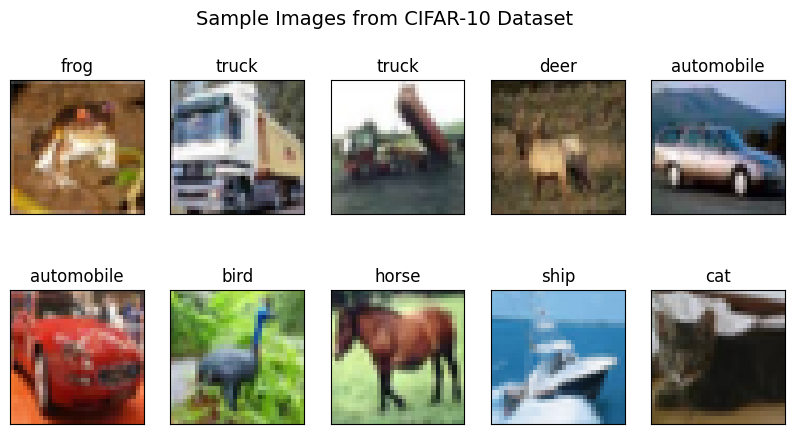

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([]); plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=14)
plt.show()

<h5>Step 2: Data Augmentation</h5>

In [4]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

<h5>Step 3a: Model A – CNN without BatchNorm/Dropout</h5>

In [5]:
modelA = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='softmax')
])
modelA.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<h5>Step 3b: Model B – CNN with BatchNorm & Dropout</h5>

In [6]:
modelB = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(32, activation='softmax')
])
modelB.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

<h5>Step 4: Train both models</h5>

In [7]:
historyA = modelA.fit(datagen.flow(x_train, y_train, batch_size=64),
                      epochs=5, validation_data=(x_test, y_test), verbose=1)

historyB = modelB.fit(datagen.flow(x_train, y_train, batch_size=64),
                      epochs=5, validation_data=(x_test, y_test), verbose=1)

Epoch 1/5


C:\Users\Sakshi Jadhav\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.3939 - loss: 1.6979 - val_accuracy: 0.4983 - val_loss: 1.4468
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.4974 - loss: 1.4067 - val_accuracy: 0.5739 - val_loss: 1.2207
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5447 - loss: 1.2839 - val_accuracy: 0.6121 - val_loss: 1.0960
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5746 - loss: 1.2062 - val_accuracy: 0.6307 - val_loss: 1.0638
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.5962 - loss: 1.1526 - val_accuracy: 0.6267 - val_loss: 1.0604
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.4165 - loss: 1.8963 - val_accuracy: 0.4218 - val_loss: 1.8473
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5307 - loss: 1.3547 - val_accuracy: 0.5407 - val_loss: 1.3083
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5745 - loss: 1.2229 - val_accuracy: 0.57

<h5>Step 5: Evaluate both models</h5>

In [8]:
test_lossA, test_accA = modelA.evaluate(x_test, y_test, verbose=0)
test_lossB, test_accB = modelB.evaluate(x_test, y_test, verbose=0)
print("\nModel A (Without BN & Dropout) Accuracy:", round(test_accA * 100, 2), "%")
print("Model B (With BN & Dropout) Accuracy:", round(test_accB * 100, 2), "%")


Model A (Without BN & Dropout) Accuracy: 62.67 %
Model B (With BN & Dropout) Accuracy: 66.65 %


<h5> Step 6: Plot accuracy comparison</h5>

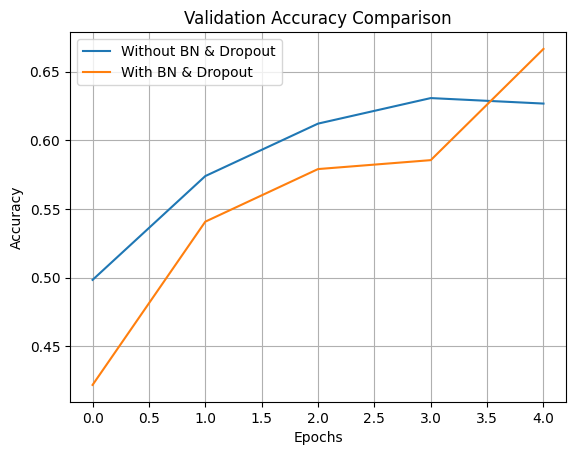

In [9]:
plt.plot(historyA.history['val_accuracy'], label='Without BN & Dropout')
plt.plot(historyB.history['val_accuracy'], label='With BN & Dropout')
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()